# E-commerce Return Analysis

## Objective
Understand revenue and return patterns across countries.

## Data Overview
- Columns: InvoiceNo, Quantity, UnitPrice, Country, etc.
- Includes returns (negative Quantity)

## Methodology
- Calculated revenue
- Separated returns
- Built return_rate by country

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df["revenue"] = df["Quantity"] * df["UnitPrice"]
df.groupby("Country")["revenue"].sum().sort_values()

Country
Saudi Arabia                131.170
Bahrain                     548.400
Czech Republic              707.720
RSA                        1002.310
Brazil                     1143.600
European Community         1291.750
Lithuania                  1661.060
Lebanon                    1693.880
USA                        1730.920
United Arab Emirates       1902.280
Malta                      2505.470
Canada                     3666.380
Iceland                    4310.000
Greece                     4710.520
Unspecified                4749.790
Poland                     7213.140
Israel                     7907.820
Singapore                  9120.390
Hong Kong                 10117.040
Austria                   10154.320
Cyprus                    12946.290
Italy                     16890.510
Denmark                   18768.140
Channel Islands           20086.290
Finland                   22326.740
Portugal                  29367.020
Norway                    35163.460
Japan               

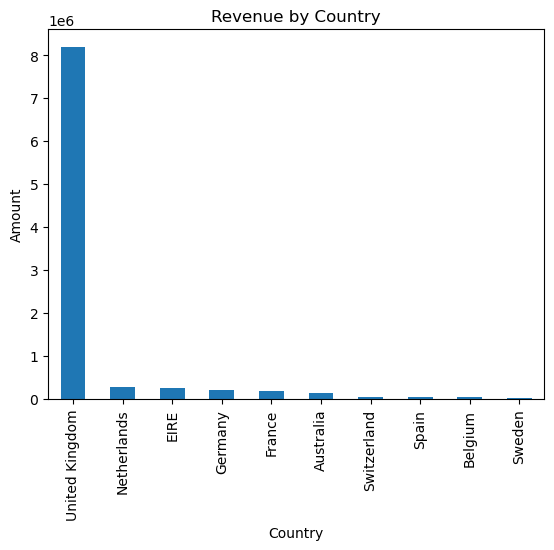

In [3]:
import matplotlib.pyplot as plt
df["revenue"] = df["Quantity"] * df["UnitPrice"]
df_grouped = df.groupby("Country")["revenue"].sum().sort_values(ascending=False).head(10)
df_grouped.plot(kind="bar", title="Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Amount")
plt.show()


In [4]:
df["returns"] = df["Quantity"] < 0

df.groupby("Country")["returns"].sum()

Country
Australia                 74
Austria                    3
Bahrain                    1
Belgium                   38
Brazil                     0
Canada                     0
Channel Islands           10
Cyprus                     8
Czech Republic             5
Denmark                    9
EIRE                     302
European Community         1
Finland                   10
France                   149
Germany                  453
Greece                     1
Hong Kong                  4
Iceland                    0
Israel                     2
Italy                     45
Japan                     37
Lebanon                    0
Lithuania                  0
Malta                     15
Netherlands                8
Norway                    14
Poland                    11
Portugal                  18
RSA                        0
Saudi Arabia               1
Singapore                  7
Spain                     48
Sweden                    11
Switzerland               35
USA   

In [5]:
df["orders"] = df["Quantity"] > 0
df.groupby("Country")["orders"].sum()
df.groupby("Country")[["orders", "returns"]].sum()

,orders,returns
Country,,
Australia,1185,74
Austria,398,3
Bahrain,18,1
Belgium,2031,38
Brazil,32,0
Canada,151,0
Channel Islands,748,10
Cyprus,614,8
Czech Republic,25,5


In [6]:
grouped = df.groupby("Country")[["orders", "returns", "revenue"]].sum()
grouped["return_rate"] = grouped["returns"] / grouped["orders"]
grouped.sort_values(["revenue", "return_rate"], ascending=[False, False])

,orders,returns,revenue,return_rate
Country,,,,
United Kingdom,486286,9192,8187806.364,0.018902
Netherlands,2363,8,284661.540,0.003386
EIRE,7894,302,263276.820,0.038257
Germany,9042,453,221698.210,0.050100
France,8408,149,197403.900,0.017721
Australia,1185,74,137077.270,0.062447
Switzerland,1967,35,56385.350,0.017794
Spain,2485,48,54774.580,0.019316
Belgium,2031,38,40910.960,0.018710


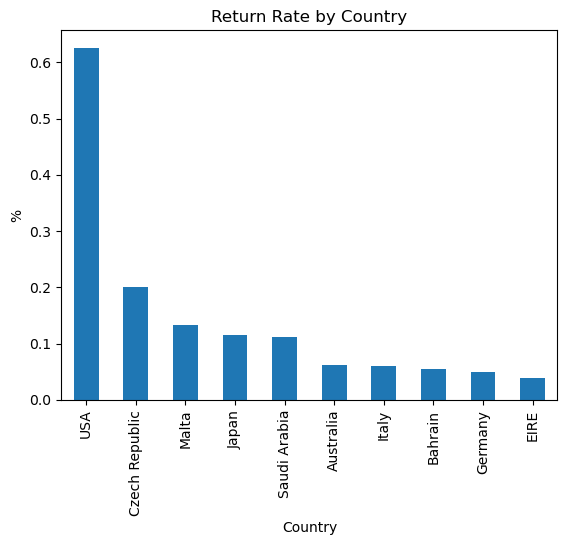

In [7]:
df["returns"] = df["Quantity"] < 0
df["orders"] = df["Quantity"] > 0
grouped = df.groupby("Country")[["orders", "returns", "revenue"]].sum()
grouped["return_rate"] = grouped["returns"] / grouped["orders"]
grouped.sort_values("return_rate", ascending=False).head(10)["return_rate"].plot(kind="bar", title="Return Rate by Country")
plt.xlabel("Country")
plt.ylabel("%")
plt.show()

In [8]:
df[df["Country"].isin(["Germany", "Japan", "Australia"])]
df_selected = df[df["Country"].isin(["Germany", "Japan", "Australia"])]
df_selected.groupby("Description")["Quantity"].sum()

Description
 50'S CHRISTMAS GIFT BAG LARGE        60
 DOLLY GIRL BEAKER                   284
 I LOVE LONDON MINI BACKPACK          52
 RED SPOT GIFT BAG LARGE              48
 SET 2 TEA TOWELS I LOVE LONDON       48
                                    ... 
ZINC HEART LATTICE T-LIGHT HOLDER     12
ZINC METAL HEART DECORATION           12
ZINC T-LIGHT HOLDER STAR LARGE        24
ZINC T-LIGHT HOLDER STARS SMALL       24
ZINC WILLIE WINKIE  CANDLE STICK      60
Name: Quantity, Length: 1831, dtype: int64

In [9]:
df_selected.groupby(["Country", "Description"])["Quantity"].sum().sort_values()

Country    Description                    
Germany    TRAVEL CARD WALLET KEEP CALM        -20
           SET OF 3 BABUSHKA STACKING TINS      -6
Australia  RED RETROSPOT TISSUE BOX             -5
Germany    BLUE PADDED SOFT MOBILE              -3
           GROW YOUR OWN PLANT IN A CAN         -3
                                              ... 
Australia  RED TOADSTOOL LED NIGHT LIGHT      1344
           RED  HARMONICA IN BOX              1704
           RABBIT NIGHT LIGHT                 1884
           MINI PAINT SET VINTAGE             2916
Japan      RABBIT NIGHT LIGHT                 3401
Name: Quantity, Length: 2529, dtype: int64

In [10]:
df_selected.groupby("Description")["returns"].sum()

Description
 50'S CHRISTMAS GIFT BAG LARGE       0
 DOLLY GIRL BEAKER                   0
 I LOVE LONDON MINI BACKPACK         0
 RED SPOT GIFT BAG LARGE             0
 SET 2 TEA TOWELS I LOVE LONDON      0
                                    ..
ZINC HEART LATTICE T-LIGHT HOLDER    0
ZINC METAL HEART DECORATION          0
ZINC T-LIGHT HOLDER STAR LARGE       0
ZINC T-LIGHT HOLDER STARS SMALL      0
ZINC WILLIE WINKIE  CANDLE STICK     0
Name: returns, Length: 1831, dtype: int64

In [11]:
returns_df = df[df["Quantity"] < 0]
returns_df[returns_df["Country"].isin(["Germany", "Japan", "Australia"])]
returns_df_selected = returns_df[returns_df["Country"].isin(["Germany", "Japan", "Australia"])]
returns_df_selected.groupby(["Country", "Description"])["Quantity"].sum()
grouped_returns = returns_df_selected.groupby(["Country", "Description"])["Quantity"].sum()
grouped_returns.sort_values()

Country    Description                       
Japan      ROUND SNACK BOXES SET OF 4 FRUITS    -624
Germany    BOYS ALPHABET IRON ON PATCHES        -288
Australia  RIBBON REEL SNOWY VILLAGE            -120
           COTTON APRON PANTRY DESIGN           -100
           HOMEMADE JAM SCENTED CANDLES          -86
                                                ... 
Germany    FAMILY ALBUM WHITE PICTURE FRAME       -1
           FELT FARM ANIMAL RABBIT                -1
           GLASS  SONGBIRD STORAGE JAR            -1
           CHILDREN'S CIRCUS PARADE MUG           -1
Japan      VINTAGE DONKEY TAIL GAME               -1
Name: Quantity, Length: 354, dtype: int64

## Recommendations

- Prioritize Germany for return reduction (high impact)
- Investigate return causes in Japan and Australia (high rates)
- Optimize product descriptions and logistics in high-return regions

## Key Insights

- UK dominates revenue but has moderate return rate
- Germany and Australia show high revenue and high return rates
- Japan has the highest return rate but lower revenue
- Return patterns differ by country, not by product

## Recommendations

- Adjust product strategy per country
- Improve product descriptions in high-return regions
- Analyze customer expectations locally
- Review logistics and delivery issues